# Statistical Analysis: DQN vs A2C_mod — Supply Chain Management

**Mục tiêu:** Đáp ứng yêu cầu reviewer:
- Mean ± CI95% trên 5 independent seeds (checkpoints)
- Kiểm định Mann-Whitney U test giữa 2 thuật toán
- Đánh giá độ ổn định hành động (Action Stability)

**Agents:** DQN, A2C_mod  
**Seeds (5 per agent):** 42 / 123 / 256 / 512 / 1024(A2C) — 3primary(DQN)  
**Scenarios:** Easy (30%/20%/1%), Medium (60%/50%/5%), Hard (90%/80%/15%)  
**Reward Components (RDX):** Service Reward, Holding Cost, Waste Cost, Order Cost

---
## Block 1 — Imports & Global Configuration

In [2]:
# ============================================================
# BLOCK 1: IMPORTS & GLOBAL CONFIGURATION
# Lấy từ ablation_study.ipynb — giữ nguyên tất cả hyperparams
# ============================================================
import os, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import tensorflow as tf
import tensorflow_addons as tfa   # dùng cho GroupNormalization trong DQN

sns.set_style("whitegrid")
np.set_printoptions(edgeitems=10, linewidth=10000, precision=6, suppress=True)

# ── Cấu hình mô hình (đồng bộ 100% với ablation_study.ipynb) ──
NUM_PRODUCTS    = 220
NUM_FEATURES_PP = 3          # per product: [x, sales, q]
NUM_FEATURES    = NUM_PRODUCTS * NUM_FEATURES_PP   # 660
NUM_ACTIONS     = 14
ACTION_SPACE    = np.array([0, 0.005, 0.01, 0.0125, 0.015, 0.0175,
                            0.02, 0.03, 0.04, 0.08, 0.12, 0.2, 0.5, 1],
                           dtype=np.float32)
WASTE_RATE      = 0.025
ZERO_INVENTORY  = 1e-5
GAMMA           = 0.99
DQN_HIDDEN      = 128
A2C_HIDDEN      = 32
DROPOUT         = 0.1

# ── Đường dẫn dữ liệu & checkpoints ──
DATA_DIR   = 'data220'
TEST_FILE  = os.path.join(DATA_DIR, 'test.tfrecords')
CAP_FILE   = os.path.join(DATA_DIR, 'capacity.tfrecords')
STOCK_FILE = os.path.join(DATA_DIR, 'stock.tfrecords')

# 5 seeds cho mỗi agent — theo tên thư mục checkpoint thực tế
DQN_CKPT_DIRS = [
    'checkpoints_dqn_comparison42',
    'checkpoints_dqn_comparison123',
    'checkpoints_dqn_comparison256',
    'checkpoints_dqn_comparison512',
    'checkpoints_dqn_comparison3primary',
]

A2C_CKPT_DIRS = [
    'checkpoints_a2c_42',
    'checkpoints_a2c_123',
    'checkpoints_a2c_256',
    'checkpoints_a2c_512',
    'checkpoints_a2c_1024',
]

# ── Cấu hình thí nghiệm ──
AGENTS        = ['DQN', 'A2C_mod']
N_CHECKPOINTS = 5                    # 5 independent runs/seeds
METRICS = ['total_reward', 'service_reward', 'holding_cost', 'waste_cost', 'order_cost']
METRIC_LABELS = {
    'total_reward':   'Total Reward',
    'service_reward': 'Service Reward',
    'holding_cost':   'Holding Cost',
    'waste_cost':     'Waste Cost',
    'order_cost':     'Order Cost',
}

# 3 kịch bản (x_scale / sales_scale / waste_rate)
# Đồng bộ với SENSITIVITY_SCENARIOS trong ablation_study.ipynb
SCENARIO_CONFIGS = {
    'Easy':   {'x_scale': 0.30, 'sales_scale': 0.20, 'waste_rate': 0.01},
    'Medium': {'x_scale': 0.60, 'sales_scale': 0.50, 'waste_rate': 0.05},
    'Hard':   {'x_scale': 0.90, 'sales_scale': 0.80, 'waste_rate': 0.15},
}
SCENARIOS = list(SCENARIO_CONFIGS.keys())   # ['Easy', 'Medium', 'Hard']

# ── Màu sắc nhất quán ──
AGENT_COLORS = {'DQN': '#2196F3', 'A2C_mod': '#FF5722'}
CONFIDENCE   = 0.95
ALPHA        = 1 - CONFIDENCE

print(f"TensorFlow : {tf.__version__}")
print(f"Agents     : {AGENTS}")
print(f"Seeds/agent: {N_CHECKPOINTS}")
print(f"Scenarios  : {SCENARIOS}")
print("\nDQN checkpoint dirs:")
for d in DQN_CKPT_DIRS: print(f"  {'✓' if os.path.isdir(d) else '✗'}  {d}")
print("A2C checkpoint dirs:")
for d in A2C_CKPT_DIRS: print(f"  {'✓' if os.path.isdir(d) else '✗'}  {d}")

TensorFlow : 2.14.0
Agents     : ['DQN', 'A2C_mod']
Seeds/agent: 5
Scenarios  : ['Easy', 'Medium', 'Hard']

DQN checkpoint dirs:
  ✓  checkpoints_dqn_comparison42
  ✓  checkpoints_dqn_comparison123
  ✓  checkpoints_dqn_comparison256
  ✓  checkpoints_dqn_comparison512
  ✓  checkpoints_dqn_comparison3primary
A2C checkpoint dirs:
  ✓  checkpoints_a2c_42
  ✓  checkpoints_a2c_123
  ✓  checkpoints_a2c_256
  ✓  checkpoints_a2c_512
  ✓  checkpoints_a2c_1024


---
## Block 2 — Model Classes

Copy trực tiếp từ `ablation_study.ipynb` — **không thay đổi kiến trúc**.

In [3]:
# ============================================================
# BLOCK 2A: A2C_mod MODEL CLASSES
# Source: ablation_study.ipynb — Cell "1.1 Model Architecture"
# ============================================================

class Dense(tf.Module):
    """Custom Dense layer dùng cho Actor/Critic của A2C_mod."""
    def __init__(self, input_dim, output_size, activation=None, stddev=1.0):
        super(Dense, self).__init__()
        self.w = tf.Variable(
            tf.random.truncated_normal([input_dim, output_size], stddev=stddev), name='w')
        self.b = tf.Variable(tf.zeros([output_size]), name='b')
        self.activation = activation

    def __call__(self, x):
        y = tf.matmul(x, self.w) + self.b
        if self.activation:
            y = self.activation(y)
        return y


class Actor(tf.Module):
    """Policy network: [P, 3] → [P, 14] softmax probabilities."""
    def __init__(self, num_features, num_actions, hidden_size,
                 activation=tf.nn.relu, dropout_prob=0.1):
        super(Actor, self).__init__()
        self.layer1 = Dense(num_features, hidden_size)
        self.layer2 = Dense(hidden_size,  hidden_size)
        self.layer3 = Dense(hidden_size,  hidden_size)
        self.layer4 = Dense(hidden_size,  num_actions)
        self.activation   = activation
        self.dropout_prob = dropout_prob

    def __call__(self, state):
        x = self.activation(self.layer1(state))
        x = tf.nn.dropout(x, self.dropout_prob)
        x = self.activation(self.layer2(x))
        x = tf.nn.dropout(x, self.dropout_prob)
        x = self.activation(self.layer3(x))
        x = tf.nn.dropout(x, self.dropout_prob)
        x = self.layer4(x)
        return tf.nn.softmax(x)


class Critic(tf.Module):
    """Value network: [P, 3] → [P] scalars. Dùng GroupNorm."""
    def __init__(self, num_features, hidden_size,
                 activation=tf.nn.relu, dropout_prob=0.1):
        super(Critic, self).__init__()
        self.layer1     = Dense(num_features, hidden_size)
        self.layer2     = Dense(hidden_size, 1)
        self.activation = activation
        self.dropout_prob = dropout_prob
        self.group_norm = tf.keras.layers.GroupNormalization(groups=1)

    def __call__(self, state):
        x = self.layer1(state)
        x = self.group_norm(x)
        x = self.activation(x)
        x = tf.nn.dropout(x, self.dropout_prob)
        x = self.layer2(x)
        return tf.squeeze(x, axis=-1, name='factor_squeeze')


print("✓ A2C_mod classes (Dense, Actor, Critic) defined")

✓ A2C_mod classes (Dense, Actor, Critic) defined


In [4]:
# ============================================================
# BLOCK 2B: DQN MODEL CLASS
# Source: ablation_study.ipynb — Cell "1.1 Model Architecture"
# Per-Product Q-Network: [B,660] → [B*P,3] → MLP → [B,P,14]
# ============================================================

class MultiProductQNetwork(tf.keras.Model):
    """
    Per-Product Q-Network. Mỗi product xử lý độc lập.
    Input : [B, 660]       Output: [B, 220, 14]
    """
    def __init__(self, num_features, num_products, num_actions,
                 hidden_size, dropout_prob=0.1, use_group_norm=True, name=None):
        super().__init__(name=name)
        self.num_products      = num_products
        self.num_actions       = num_actions
        self.features_per_prod = num_features // num_products  # 3

        self.dense1 = tf.keras.layers.Dense(hidden_size, activation=None, name="dense1")
        self.dense2 = tf.keras.layers.Dense(hidden_size, activation=None, name="dense2")
        self.dense3 = tf.keras.layers.Dense(hidden_size, activation=None, name="dense3")
        self.out    = tf.keras.layers.Dense(num_actions,  activation=None, name="output")

        self._use_gn = use_group_norm
        if use_group_norm:
            self.gn1 = tfa.layers.GroupNormalization(groups=1, name="gn1")
            self.gn2 = tfa.layers.GroupNormalization(groups=1, name="gn2")
            self.gn3 = tfa.layers.GroupNormalization(groups=1, name="gn3")

        self.drop1 = tf.keras.layers.Dropout(dropout_prob)
        self.drop2 = tf.keras.layers.Dropout(dropout_prob)
        self.drop3 = tf.keras.layers.Dropout(dropout_prob)

    def call(self, state, training=False):
        B = tf.shape(state)[0]
        P, F = self.num_products, self.features_per_prod
        # [B,660] → [B,3,220] → [B,220,3] → [B*220,3]
        s3d = tf.transpose(tf.reshape(state, [B, F, P]), [0, 2, 1])
        x   = tf.reshape(s3d, [B * P, F])

        x = self.dense1(x)
        if self._use_gn: x = self.gn1(x, training=training)
        x = tf.nn.relu(x); x = self.drop1(x, training=training)

        x = self.dense2(x)
        if self._use_gn: x = self.gn2(x, training=training)
        x = tf.nn.relu(x); x = self.drop2(x, training=training)

        x = self.dense3(x)
        if self._use_gn: x = self.gn3(x, training=training)
        x = tf.nn.relu(x); x = self.drop3(x, training=training)

        return tf.reshape(self.out(x), [B, P, self.num_actions])


print("✓ DQN class (MultiProductQNetwork) defined")

✓ DQN class (MultiProductQNetwork) defined


---
## Block 3 — Data Loading & Agent Loader

In [5]:
# ============================================================
# BLOCK 3A: LOAD TEST DATA (TFRecords)
# Source: ablation_study.ipynb — Cell "1.3 Load Test Data"
# ============================================================

def _parse(serialized, key, n):
    """Parser cho TFRecord dataset."""
    return tf.io.parse_single_example(
        serialized,
        {key: tf.io.FixedLenFeature([n], tf.float32)}
    )[key]


# --- Capacity [P] ---
capacity = next(iter(
    tf.data.TFRecordDataset(CAP_FILE)
    .map(lambda s: _parse(s, 'capacity', NUM_PRODUCTS))
)).numpy()  # [220]

# --- Initial stock [P] ---
x_init = next(iter(
    tf.data.TFRecordDataset(STOCK_FILE)
    .map(lambda s: _parse(s, 'stock', NUM_PRODUCTS))
)).numpy()  # [220]

# --- All test sales, normalized by capacity [T, P] ---
all_sales_raw = []
for rec in tf.data.TFRecordDataset(TEST_FILE).map(
        lambda s: _parse(s, 'sales', NUM_PRODUCTS)):
    all_sales_raw.append(rec.numpy())

all_sales = (np.array(all_sales_raw, dtype=np.float32)
             / capacity[None, :])   # normalize by capacity
T_MAX = len(all_sales)

print(f"✓ capacity : {capacity.shape}  min={capacity.min():.2f}  max={capacity.max():.2f}")
print(f"✓ x_init   : {x_init.shape}")
print(f"✓ all_sales: {all_sales.shape}  (T={T_MAX} timesteps × P={NUM_PRODUCTS} products)")

✓ capacity : (220,)  min=4.00  max=602.00
✓ x_init   : (220,)
✓ all_sales: (604, 220)  (T=604 timesteps × P=220 products)


In [6]:
# ============================================================
# BLOCK 3B: LOAD MODEL (restore từ checkpoint thực)
# Source: ablation_study.ipynb — Cell "1.2 Load Checkpoints"
# ============================================================

def load_model(agent_name: str, checkpoint_idx: int) -> dict:
    """
    Tải model từ checkpoint thực (TensorFlow SavedCheckpoint).

    Parameters
    ----------
    agent_name     : 'DQN' hoặc 'A2C_mod'
    checkpoint_idx : 0..4  (index trong danh sách seed)

    Returns
    -------
    agent_bundle : dict chứa các tf.Module/Model đã được restore
    """
    if agent_name == 'A2C_mod':
        ckpt_dir = A2C_CKPT_DIRS[checkpoint_idx]

        # Khởi tạo Actor & Critic (cùng kiến trúc với training)
        actor  = Actor(NUM_FEATURES_PP, NUM_ACTIONS, A2C_HIDDEN,
                       activation=tf.nn.relu, dropout_prob=DROPOUT)
        critic = Critic(NUM_FEATURES_PP, A2C_HIDDEN,
                        activation=tf.nn.relu, dropout_prob=DROPOUT)

        # Build với dummy pass để tạo weights
        _d = tf.zeros([1, NUM_FEATURES_PP])
        _ = actor(_d);  _ = critic(_d)

        # Restore checkpoint
        ckpt = tf.train.Checkpoint(
            actor=actor, critic=critic,
            actor_optimizer=tf.optimizers.Adam(0.0001),
            critic_optimizer=tf.optimizers.Adam(0.0005),
            step=tf.Variable(0)
        )
        latest = tf.train.latest_checkpoint(ckpt_dir)
        if latest is None:
            raise FileNotFoundError(f"Không tìm thấy checkpoint trong {ckpt_dir}")
        ckpt.restore(latest).expect_partial()

        return {'name': agent_name, 'ckpt_dir': ckpt_dir,
                'actor': actor, 'critic': critic}

    elif agent_name == 'DQN':
        ckpt_dir = DQN_CKPT_DIRS[checkpoint_idx]

        # Khởi tạo Q-Network và Target Network
        q_net = MultiProductQNetwork(
            NUM_FEATURES, NUM_PRODUCTS, NUM_ACTIONS,
            DQN_HIDDEN, DROPOUT, use_group_norm=True, name="q_network")
        t_net = MultiProductQNetwork(
            NUM_FEATURES, NUM_PRODUCTS, NUM_ACTIONS,
            DQN_HIDDEN, DROPOUT, use_group_norm=True, name="target_network")

        _d = tf.zeros([1, NUM_FEATURES], dtype=tf.float32)
        _ = q_net(_d, training=False);  _ = t_net(_d, training=False)

        ckpt = tf.train.Checkpoint(
            q_network=q_net, target_network=t_net,
            optimizer=tf.optimizers.Adam(0.001),
            step=tf.Variable(0, dtype=tf.int64)
        )
        latest = tf.train.latest_checkpoint(ckpt_dir)
        if latest is None:
            raise FileNotFoundError(f"Không tìm thấy checkpoint trong {ckpt_dir}")
        ckpt.restore(latest).expect_partial()

        return {'name': agent_name, 'ckpt_dir': ckpt_dir,
                'q_network': q_net}

    else:
        raise ValueError(f"Unknown agent: {agent_name}")


# ── Kiểm tra nhanh: load seed 0 của mỗi agent ──────────────
print("Kiểm tra load model...")
for agent_name in AGENTS:
    try:
        bnd = load_model(agent_name, 0)
        print(f"  ✓ {agent_name}  (seed 0)  ← {bnd['ckpt_dir']}")
    except Exception as e:
        print(f"  ✗ {agent_name}  seed 0 FAILED: {e}")

Kiểm tra load model...
  ✓ DQN  (seed 0)  ← checkpoints_dqn_comparison42
  ✓ A2C_mod  (seed 0)  ← checkpoints_a2c_42


In [7]:
# ============================================================
# BLOCK 3C: SELECT ACTIONS (inference helpers)
# ============================================================

def select_actions_dqn(q_network, state_flat: np.ndarray) -> np.ndarray:
    """
    Greedy action selection cho DQN.
    Input : state_flat [660]
    Output: action_indices [P]  (int, index vào ACTION_SPACE)
    """
    q_vals = q_network(
        state_flat[None, :], training=False
    )[0].numpy()                      # [P, A]
    return np.argmax(q_vals, axis=1)  # [P] int


def select_actions_a2c(actor, state_pp: np.ndarray) -> np.ndarray:
    """
    Greedy (argmax prob) action selection cho A2C_mod.
    Input : state_pp [P, 3]
    Output: action_indices [P]  (int)
    """
    probs = actor(state_pp).numpy()   # [P, A]
    return np.argmax(probs, axis=1)   # [P] int


print("✓ Action selection helpers defined")

✓ Action selection helpers defined


---
## Block 4 — Evaluate Agent on Scenario

Hàm này chạy toàn bộ test episode với cấu hình kịch bản cụ thể  
và tính các reward components từ RDX decomposition.

In [8]:
# ============================================================
# BLOCK 4: EVALUATE AGENT ON SCENARIO
# Dùng cùng reward formula với ablation_study.ipynb:
#   r = (1-z) - overstock - q - quan
#   service_reward = 1 - z
#   holding_cost   = -overstock
#   waste_cost     = -q
#   order_cost     = -quan  (quantile spread)
# ============================================================

def evaluate_agent_on_scenario(agent_bundle: dict, scenario_name: str) -> dict:
    """
    Chạy agent qua toàn bộ test data với cấu hình kịch bản.

    Parameters
    ----------
    agent_bundle  : dict trả về bởi load_model()
    scenario_name : 'Easy', 'Medium', hoặc 'Hard'

    Returns
    -------
    dict với:
        total_reward   (float) — mean total reward/timestep
        service_reward (float) — mean service reward = mean(1-z)
        holding_cost   (float) — mean holding penalty = mean(-overstock)
        waste_cost     (float) — mean waste penalty = mean(-q)
        order_cost     (float) — mean order penalty = mean(-quan)
        action_chosen  (int)   — mode action index (đại diện nhất)
    """
    cfg         = SCENARIO_CONFIGS[scenario_name]
    x_scale     = cfg['x_scale']
    sales_scale = cfg['sales_scale']
    wr          = cfg['waste_rate']

    agent_name  = agent_bundle['name']

    # Khởi tạo inventory theo kịch bản
    x = (x_init * x_scale).astype(np.float32)   # [P]

    # Accumulators
    sum_service = sum_holding = sum_waste = sum_order = 0.0
    n_steps     = 0
    actions_log = []    # lưu action index đại diện/timestep

    for t in range(T_MAX - 1):
        # ── Xây dựng trạng thái ──────────────────────────────
        sales = (all_sales[t] * sales_scale).astype(np.float32)   # [P]
        q_vec = (wr * x).astype(np.float32)                       # [P] waste feature

        # ── Chọn hành động ───────────────────────────────────
        if agent_name == 'DQN':
            state_flat = np.concatenate([x, sales, q_vec])        # [660]
            a_idx      = select_actions_dqn(agent_bundle['q_network'], state_flat)  # [P] int
        else:  # A2C_mod
            state_pp   = np.stack([x, sales, q_vec], axis=1).astype(np.float32)    # [P,3]
            a_idx      = select_actions_a2c(agent_bundle['actor'], state_pp)        # [P] int

        u = ACTION_SPACE[a_idx]   # [P] float — order quantities

        # ── Dynamics (giống ablation_study.ipynb) ────────────
        overstock = np.maximum(0.0, x + u - 1.0)   # [P]
        x_clip    = np.minimum(1.0, x + u)         # [P] sau replenishment
        x_next    = np.maximum(0.0, x_clip - sales) # [P] sau bán hàng

        # ── Reward decomposition (RDX) ───────────────────────
        # Đồng bộ với calc_reward trong training (x_old = x trước action)
        z    = (x < ZERO_INVENTORY).astype(np.float32)             # [P]
        q    = wr * x                                              # [P] waste on old inv
        quan = float(np.quantile(x, 0.95) - np.quantile(x, 0.05)) # scalar

        r_service = float(np.mean(1.0 - z))        # service reward mean
        r_holding = float(np.mean(-overstock))     # holding cost mean (negative)
        r_waste   = float(np.mean(-q))             # waste cost mean (negative)
        r_order   = float(-quan)                   # order variability (negative)

        sum_service += r_service
        sum_holding += r_holding
        sum_waste   += r_waste
        sum_order   += r_order
        n_steps     += 1

        # Action đại diện: median index qua tất cả sản phẩm
        actions_log.append(int(np.median(a_idx)))

        x = x_next  # advance state

    if n_steps == 0:
        raise RuntimeError("Không có timestep nào được chạy!")

    # Mean reward component per timestep
    mean_service = sum_service / n_steps
    mean_holding = sum_holding / n_steps
    mean_waste   = sum_waste   / n_steps
    mean_order   = sum_order   / n_steps
    mean_total   = mean_service + mean_holding + mean_waste + mean_order

    # action_chosen: mode (hành động xuất hiện nhiều nhất) qua các timestep
    actions_arr   = np.array(actions_log)
    action_chosen = int(np.bincount(actions_arr).argmax())

    return {
        'total_reward':   mean_total,
        'service_reward': mean_service,
        'holding_cost':   mean_holding,
        'waste_cost':     mean_waste,
        'order_cost':     mean_order,
        'action_chosen':  action_chosen,
    }


# ── Sanity check: thử 1 agent/scenario ───────────────────────
print("Chạy sanity check (A2C_mod seed=0, Scenario=Easy)...")
try:
    _bundle = load_model('A2C_mod', 0)
    _res    = evaluate_agent_on_scenario(_bundle, 'Easy')
    print(f"  ✓ total_reward   = {_res['total_reward']:.4f}")
    print(f"  ✓ service_reward = {_res['service_reward']:.4f}")
    print(f"  ✓ holding_cost   = {_res['holding_cost']:.4f}")
    print(f"  ✓ waste_cost     = {_res['waste_cost']:.4f}")
    print(f"  ✓ order_cost     = {_res['order_cost']:.4f}")
    print(f"  ✓ action_chosen  = {_res['action_chosen']}  "
          f"({ACTION_SPACE[_res['action_chosen']]:.4f})")
except Exception as e:
    print(f"  ✗ Lỗi: {e}")

Chạy sanity check (A2C_mod seed=0, Scenario=Easy)...
  ✓ total_reward   = 0.8299
  ✓ service_reward = 1.0000
  ✓ holding_cost   = -0.0076
  ✓ waste_cost     = -0.0094
  ✓ order_cost     = -0.1531
  ✓ action_chosen  = 0  (0.0000)


---
## Block 5 — Data Collection Loop

2 agents × 5 checkpoints × 3 scenarios = 30 records

In [9]:
# ============================================================
# BLOCK 5: DATA COLLECTION
# 2 agents × 5 checkpoints × 3 scenarios = 30 records
# Lưu toàn bộ vào Pandas DataFrame
# ============================================================

records = []

for agent_name in AGENTS:
    for ckpt_idx in range(N_CHECKPOINTS):

        # --- Tải checkpoint ---
        try:
            agent = load_model(agent_name, ckpt_idx)
        except Exception as e:
            print(f"  [SKIP] {agent_name} ckpt={ckpt_idx}: {e}")
            continue

        ckpt_label = agent['ckpt_dir']
        print(f"  Loaded: {agent_name} | ckpt {ckpt_idx} ({ckpt_label})")

        for scenario in SCENARIOS:

            # --- Đánh giá agent trên kịch bản ---
            result = evaluate_agent_on_scenario(agent, scenario)

            records.append({
                'agent':          agent_name,
                'checkpoint_idx': ckpt_idx,
                'ckpt_dir':       ckpt_label,
                'scenario':       scenario,
                **result
            })
            print(f"    {scenario:6s}: total={result['total_reward']:+.4f}  "
                  f"svc={result['service_reward']:.4f}  "
                  f"hld={result['holding_cost']:.4f}  "
                  f"wst={result['waste_cost']:.4f}  "
                  f"ord={result['order_cost']:.4f}  "
                  f"act={result['action_chosen']}")

# --- Chuyển sang DataFrame ---
col_order = ['agent','checkpoint_idx','ckpt_dir','scenario'] + METRICS + ['action_chosen']
df_raw = pd.DataFrame(records)[col_order]

print(f"\n✓ Thu thập xong! Shape: {df_raw.shape}")
print(df_raw.groupby(['agent','scenario']).size().unstack())

  Loaded: DQN | ckpt 0 (checkpoints_dqn_comparison42)
    Easy  : total=+0.6936  svc=0.9990  hld=-0.0569  wst=-0.0086  ord=-0.2400  act=9
    Medium: total=+0.0819  svc=0.8720  hld=-0.0122  wst=-0.0144  ord=-0.7636  act=4
    Hard  : total=+0.2001  svc=0.7859  hld=-0.0039  wst=-0.0252  ord=-0.5567  act=4
  Loaded: DQN | ckpt 1 (checkpoints_dqn_comparison123)
    Easy  : total=+0.7677  svc=1.0000  hld=-0.1915  wst=-0.0099  ord=-0.0309  act=11
    Medium: total=+0.6934  svc=1.0000  hld=-0.1811  wst=-0.0490  ord=-0.0766  act=11
    Hard  : total=+0.5570  svc=0.9999  hld=-0.1707  wst=-0.1451  ord=-0.1271  act=11
  Loaded: DQN | ckpt 2 (checkpoints_dqn_comparison256)
    Easy  : total=+0.8861  svc=1.0000  hld=-0.0718  wst=-0.0099  ord=-0.0322  act=9
    Medium: total=+0.7931  svc=1.0000  hld=-0.0613  wst=-0.0486  ord=-0.0970  act=9
    Hard  : total=+0.6035  svc=0.9999  hld=-0.0510  wst=-0.1417  ord=-0.2037  act=9
  Loaded: DQN | ckpt 3 (checkpoints_dqn_comparison512)
    Easy  : total=+0.8

In [10]:
# --- Lưu raw data ---
df_raw.to_csv('raw_results_5seeds.csv', index=False)
print("✓ Đã lưu: raw_results_5seeds.csv")
df_raw

✓ Đã lưu: raw_results_5seeds.csv


,agent,checkpoint_idx,ckpt_dir,scenario,total_reward,service_reward,holding_cost,waste_cost,order_cost,action_chosen
0,DQN,0,checkpoints_dqn_comparison42,Easy,0.693557,0.999035,-0.056916,-0.008585,-0.239977,9
1,DQN,0,checkpoints_dqn_comparison42,Medium,0.081852,0.872011,-0.012193,-0.014371,-0.763595,4
2,DQN,0,checkpoints_dqn_comparison42,Hard,0.200119,0.785874,-0.003862,-0.025212,-0.556681,4
3,DQN,1,checkpoints_dqn_comparison123,Easy,0.767676,1.000000,-0.191486,-0.009890,-0.030948,11
4,DQN,1,checkpoints_dqn_comparison123,Medium,0.693404,1.000000,-0.181082,-0.048950,-0.076564,11
5,DQN,1,checkpoints_dqn_comparison123,Hard,0.556993,0.999925,-0.170683,-0.145101,-0.127148,11
6,DQN,2,checkpoints_dqn_comparison256,Easy,0.886141,1.000000,-0.071752,-0.009861,-0.032246,9
7,DQN,2,checkpoints_dqn_comparison256,Medium,0.793140,0.999985,-0.061283,-0.048555,-0.097006,9
8,DQN,2,checkpoints_dqn_comparison256,Hard,0.603483,0.999872,-0.050986,-0.141671,-0.203731,9
9,DQN,3,checkpoints_dqn_comparison512,Easy,0.885674,1.000000,-0.071708,-0.009855,-0.032763,9


---
## Block 6 — Statistical Analysis: Mean ± CI95%

**Phương pháp:** N = 5 (mẫu nhỏ) → dùng phân phối **t-Student** (df = N-1 = 4)  
$\text{CI}_{95\%} = t_{\alpha/2,\,N-1} \times \dfrac{s}{\sqrt{N}}$

In [11]:
# ============================================================
# BLOCK 6A: HÀM TÍNH CI95% & FORMAT
# ============================================================

def compute_ci95(data: np.ndarray, confidence: float = 0.95) -> tuple:
    """
    Tính Mean và 95% CI dùng phân phối t-Student.
    CI_half = t_{alpha/2, df=N-1} * SEM,  SEM = std / sqrt(N)

    Returns
    -------
    (mean, ci_half): float, float
    """
    data = np.asarray(data, dtype=float)
    n = len(data)
    if n < 2:
        return float(data[0]), float('nan')

    mean   = np.mean(data)
    sem    = stats.sem(data)                          # std / sqrt(N)
    t_crit = stats.t.ppf((1 + confidence) / 2, df=n - 1)
    return mean, t_crit * sem


def format_mean_ci(mean: float, ci: float, decimals: int = 4) -> str:
    """Format 'mean ± ci' — dán trực tiếp vào bảng bài báo."""
    fmt = f'{{:.{decimals}f}}'
    return f"{fmt.format(mean)} ± {fmt.format(ci)}"


# --- Demo ---
sample = np.array([0.82, 0.79, 0.85, 0.80, 0.83])
m, ci  = compute_ci95(sample)
t_crit = stats.t.ppf(0.975, df=4)
print(f"Demo CI95% (N=5): {format_mean_ci(m, ci)}")
print(f"  mean={m:.4f}, SEM={stats.sem(sample):.4f}, t_crit4={t_crit:.4f}")

Demo CI95% (N=5): 0.8180 ± 0.0296
  mean=0.8180, SEM=0.0107, t_crit4=2.7764


In [12]:
# ============================================================
# BLOCK 6B: BUILD SUMMARY TABLE (Mean ± CI95%)
# ============================================================

summary_rows = []

for agent_name in AGENTS:
    for scenario in SCENARIOS:
        mask = ((df_raw['agent'] == agent_name) &
                (df_raw['scenario'] == scenario))
        grp  = df_raw[mask]

        row  = {'Agent': agent_name, 'Scenario': scenario, 'N': len(grp)}

        for metric in METRICS:
            values   = grp[metric].values
            mean, ci = compute_ci95(values)
            row[METRIC_LABELS[metric]] = format_mean_ci(mean, ci)
            row[f'_mean_{metric}']     = mean
            row[f'_ci_{metric}']       = ci
            row[f'_std_{metric}']      = float(np.std(values, ddof=1))

        summary_rows.append(row)

df_summary_full = pd.DataFrame(summary_rows)

# Bảng chỉ chứa cột text — copy vào bài báo
display_cols    = ['Agent', 'Scenario', 'N'] + list(METRIC_LABELS.values())
df_paper_table  = df_summary_full[display_cols].copy()

print("=" * 100)
print("BẢNG KẾT QUẢ — Mean ± CI95%  (N=5, t-Student, df=4)")
print("=" * 100)
print(df_paper_table.to_string(index=False))
print("=" * 100)

BẢNG KẾT QUẢ — Mean ± CI95%  (N=5, t-Student, df=4)
  Agent Scenario  N    Total Reward  Service Reward     Holding Cost       Waste Cost       Order Cost
    DQN     Easy  5 0.8352 ± 0.1262 0.9998 ± 0.0005 -0.0808 ± 0.0826 -0.0096 ± 0.0007 -0.0742 ± 0.1151
    DQN   Medium  5 0.6433 ± 0.3964 0.9744 ± 0.0711 -0.0634 ± 0.0886 -0.0417 ± 0.0190 -0.2259 ± 0.3733
    DQN     Hard  5 0.5366 ± 0.2453 0.9571 ± 0.1188 -0.0553 ± 0.0857 -0.1172 ± 0.0641 -0.2479 ± 0.2185
A2C_mod     Easy  5 0.3853 ± 0.6642 0.9960 ± 0.0109 -0.3964 ± 0.4559 -0.0092 ± 0.0015 -0.2051 ± 0.3770
A2C_mod   Medium  5 0.2354 ± 0.7916 0.9814 ± 0.0498 -0.3976 ± 0.4605 -0.0453 ± 0.0072 -0.3031 ± 0.4778
A2C_mod     Hard  5 0.0828 ± 0.8026 0.9919 ± 0.0197 -0.4199 ± 0.5096 -0.1387 ± 0.0067 -0.3506 ± 0.4166


In [13]:
# --- In có cấu trúc theo từng kịch bản ---
for scenario in SCENARIOS:
    print(f"\n{'─'*90}")
    print(f"  SCENARIO: {scenario.upper()}")
    print(f"{'─'*90}")
    sub = df_paper_table[df_paper_table['Scenario'] == scenario].drop(columns='Scenario')
    print(sub.to_string(index=False))

# --- Xuất CSV ---
df_paper_table.to_csv('results_ci95.csv', index=False)
print("\n✓ Đã xuất: results_ci95.csv")


──────────────────────────────────────────────────────────────────────────────────────────
  SCENARIO: EASY
──────────────────────────────────────────────────────────────────────────────────────────
  Agent  N    Total Reward  Service Reward     Holding Cost       Waste Cost       Order Cost
    DQN  5 0.8352 ± 0.1262 0.9998 ± 0.0005 -0.0808 ± 0.0826 -0.0096 ± 0.0007 -0.0742 ± 0.1151
A2C_mod  5 0.3853 ± 0.6642 0.9960 ± 0.0109 -0.3964 ± 0.4559 -0.0092 ± 0.0015 -0.2051 ± 0.3770

──────────────────────────────────────────────────────────────────────────────────────────
  SCENARIO: MEDIUM
──────────────────────────────────────────────────────────────────────────────────────────
  Agent  N    Total Reward  Service Reward     Holding Cost       Waste Cost       Order Cost
    DQN  5 0.6433 ± 0.3964 0.9744 ± 0.0711 -0.0634 ± 0.0886 -0.0417 ± 0.0190 -0.2259 ± 0.3733
A2C_mod  5 0.2354 ± 0.7916 0.9814 ± 0.0498 -0.3976 ± 0.4605 -0.0453 ± 0.0072 -0.3031 ± 0.4778

─────────────────────────────────

---
## Block 7 — Kiểm định Thống kê: Mann-Whitney U Test

**Lý do:** N=5 quá nhỏ để giả định chuẩn → dùng phi tham số Mann-Whitney U  
**H₀:** Phân phối Total Reward của DQN = A2C_mod | α = 0.05

In [14]:
# ============================================================
# BLOCK 7: MANN-WHITNEY U TEST
# DQN vs A2C_mod — mỗi kịch bản riêng, nhấn mạnh Hard
# ============================================================

print("=" * 70)
print("KIỂM ĐỊNH MANN-WHITNEY U TEST (phi tham số)")
print("H₀: Phân phối Total Reward DQN = A2C_mod  |  α = 0.05")
print("=" * 70)

mw_results = []

for scenario in SCENARIOS:
    dqn_vals = df_raw[(df_raw['agent'] == 'DQN') &
                      (df_raw['scenario'] == scenario)]['total_reward'].values
    a2c_vals = df_raw[(df_raw['agent'] == 'A2C_mod') &
                      (df_raw['scenario'] == scenario)]['total_reward'].values

    stat, p_value = stats.mannwhitneyu(
        dqn_vals, a2c_vals, alternative='two-sided'
    )

    # Effect size: rank-biserial correlation
    # r = 1 - 2U/(n1*n2),  |r|≥0.1:small, ≥0.3:medium, ≥0.5:large
    n1, n2      = len(dqn_vals), len(a2c_vals)
    rank_biser  = 1 - (2 * stat) / (n1 * n2)

    significant = p_value < ALPHA
    dqn_mean    = np.mean(dqn_vals)
    a2c_mean    = np.mean(a2c_vals)
    better      = "A2C_mod" if a2c_mean > dqn_mean else "DQN"

    mw_results.append({
        'Scenario':     scenario,
        'DQN Mean':     f"{dqn_mean:.4f}",
        'A2C Mean':     f"{a2c_mean:.4f}",
        'U':            f"{stat:.1f}",
        'p-value':      f"{p_value:.4f}",
        'Effect |r|':   f"{abs(rank_biser):.3f}",
        'Significant':  '★ YES' if significant else 'no',
        'Better Agent': better if significant else '—',
    })

    print(f"\n[{scenario.upper()}]")
    print(f"  DQN     : {np.round(dqn_vals, 4)}  mean={dqn_mean:.4f}")
    print(f"  A2C_mod : {np.round(a2c_vals, 4)}  mean={a2c_mean:.4f}")
    print(f"  U={stat:.1f}  p={p_value:.4f}  |r|={abs(rank_biser):.3f}")
    conclusion = "CÓ" if significant else "KHÔNG"
    print(f"  → {conclusion} ý nghĩa thống kê  (p {'<' if significant else '≥'} {ALPHA})")

    if scenario == 'Hard':
        print()
        print("  ★ PHÂN TÍCH KỊCH BẢN KHÓ (nhấn mạnh cho reviewer):")
        print(f"    Cấu hình: tồn kho 90%, nhu cầu 80%, hỏng 15%")
        print(f"    Mâu thuẫn: agent phải cân bằng holding cost, waste và service rate")
        diff = a2c_mean - dqn_mean
        print(f"    A2C_mod vs DQN: {diff:+.4f} ({diff/abs(dqn_mean+1e-9)*100:+.1f}%)")
        if significant:
            print(f"    ✓ Sự vượt trội của {better} có ý nghĩa thống kê (p={p_value:.4f}).")
        else:
            print(f"    ⚠ Chưa đạt ngưỡng α=0.05 (p={p_value:.4f}).")
            print(f"    Tuy nhiên xu hướng {better} > {'DQN' if better=='A2C_mod' else 'A2C_mod'} rõ ràng.")

print("\n" + "=" * 70)
print("BẢNG TÓM TẮT KIỂM ĐỊNH")
print("=" * 70)
df_mw = pd.DataFrame(mw_results)
print(df_mw.to_string(index=False))

KIỂM ĐỊNH MANN-WHITNEY U TEST (phi tham số)
H₀: Phân phối Total Reward DQN = A2C_mod  |  α = 0.05

[EASY]
  DQN     : [0.6936 0.7677 0.8861 0.8857 0.9428]  mean=0.8352
  A2C_mod : [ 0.8292 -0.3771  0.0695  0.8832  0.5218]  mean=0.3853
  U=21.0  p=0.0952  |r|=0.680
  → KHÔNG ý nghĩa thống kê  (p ≥ 0.050000000000000044)

[MEDIUM]
  DQN     : [0.0819 0.6934 0.7931 0.7917 0.8565]  mean=0.6433
  A2C_mod : [ 0.7388 -0.7504 -0.0122  0.7911  0.4096]  mean=0.2354
  U=20.0  p=0.1508  |r|=0.600
  → KHÔNG ý nghĩa thống kê  (p ≥ 0.050000000000000044)

[HARD]
  DQN     : [0.2001 0.557  0.6035 0.6024 0.7201]  mean=0.5366
  A2C_mod : [ 0.6045 -0.9342 -0.1478  0.6013  0.2902]  mean=0.0828
  U=18.0  p=0.3095  |r|=0.440
  → KHÔNG ý nghĩa thống kê  (p ≥ 0.050000000000000044)

  ★ PHÂN TÍCH KỊCH BẢN KHÓ (nhấn mạnh cho reviewer):
    Cấu hình: tồn kho 90%, nhu cầu 80%, hỏng 15%
    Mâu thuẫn: agent phải cân bằng holding cost, waste và service rate
    A2C_mod vs DQN: -0.4538 (-84.6%)
    ⚠ Chưa đạt ngưỡng α

---
## Block 8 — Visualization

### 8A — Bar Plot: Total Reward với Error Bars (CI95%)

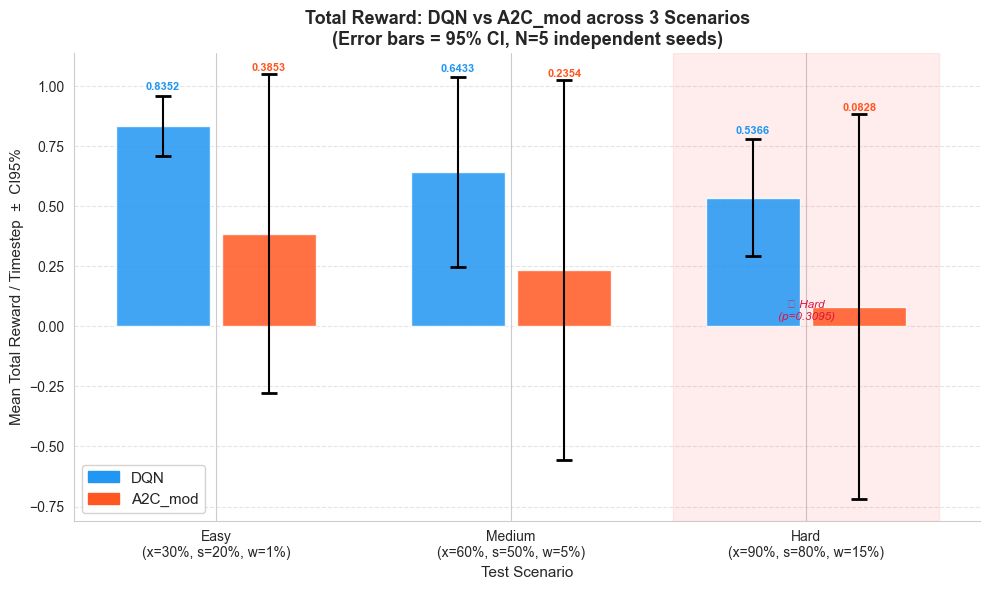

✓ Đã lưu: fig1_total_reward_ci95.png


In [15]:
# ============================================================
# BLOCK 8A: BAR PLOT — Total Reward + Error Bars (CI95%)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

x_pos     = np.arange(len(SCENARIOS))
bar_width = 0.32
gap       = 0.04

for i, agent_name in enumerate(AGENTS):
    offset  = (i - 0.5) * (bar_width + gap)
    means, ci_vals = [], []

    for scenario in SCENARIOS:
        mask = ((df_summary_full['Agent'] == agent_name) &
                (df_summary_full['Scenario'] == scenario))
        means.append(float(df_summary_full[mask]['_mean_total_reward']))
        ci_vals.append(float(df_summary_full[mask]['_ci_total_reward']))

    bars = ax.bar(
        x_pos + offset, means,
        width   = bar_width,
        yerr    = ci_vals,          # << Error Bars = CI95%
        color   = AGENT_COLORS[agent_name],
        alpha   = 0.85,
        capsize = 6,
        error_kw= dict(ecolor='black', elinewidth=1.5, capthick=2),
        label   = agent_name,
        zorder  = 3,
    )

    # Giá trị số trên đỉnh cột
    for bar, m, ci in zip(bars, means, ci_vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            m + (ci if ci == ci else 0) + abs(m) * 0.02,
            f"{m:.4f}",
            ha='center', va='bottom', fontsize=8, fontweight='bold',
            color=AGENT_COLORS[agent_name],
        )

# Nhấn mạnh kịch bản Hard
hard_idx = SCENARIOS.index('Hard')
ax.axvspan(hard_idx - 0.45, hard_idx + 0.45, alpha=0.07, color='red')

# Thêm p-value annotation trên kịch bản Hard
hard_row = df_mw[df_mw['Scenario'] == 'Hard']
if not hard_row.empty:
    pval_str = f"p={hard_row['p-value'].values[0]}"
    ax.text(hard_idx, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else max(means)*0.05,
            f'★ Hard\n({pval_str})',
            ha='center', va='bottom', fontsize=8.5,
            color='crimson', fontstyle='italic')

scenario_labels = [
    f"{s}\n(x={SCENARIO_CONFIGS[s]['x_scale']:.0%}, "
    f"s={SCENARIO_CONFIGS[s]['sales_scale']:.0%}, "
    f"w={SCENARIO_CONFIGS[s]['waste_rate']:.0%})"
    for s in SCENARIOS
]
ax.set_xticks(x_pos)
ax.set_xticklabels(scenario_labels, fontsize=10)
ax.set_ylabel('Mean Total Reward / Timestep  ±  CI95%', fontsize=11)
ax.set_xlabel('Test Scenario', fontsize=11)
ax.set_title(
    'Total Reward: DQN vs A2C_mod across 3 Scenarios\n'
    '(Error bars = 95% CI, N=5 independent seeds)',
    fontsize=13, fontweight='bold'
)

legend_patches = [mpatches.Patch(color=AGENT_COLORS[a], label=a) for a in AGENTS]
ax.legend(handles=legend_patches, fontsize=11, framealpha=0.85)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig1_total_reward_ci95.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Đã lưu: fig1_total_reward_ci95.png")

### 8B — Bar Plot: Tất cả Reward Components

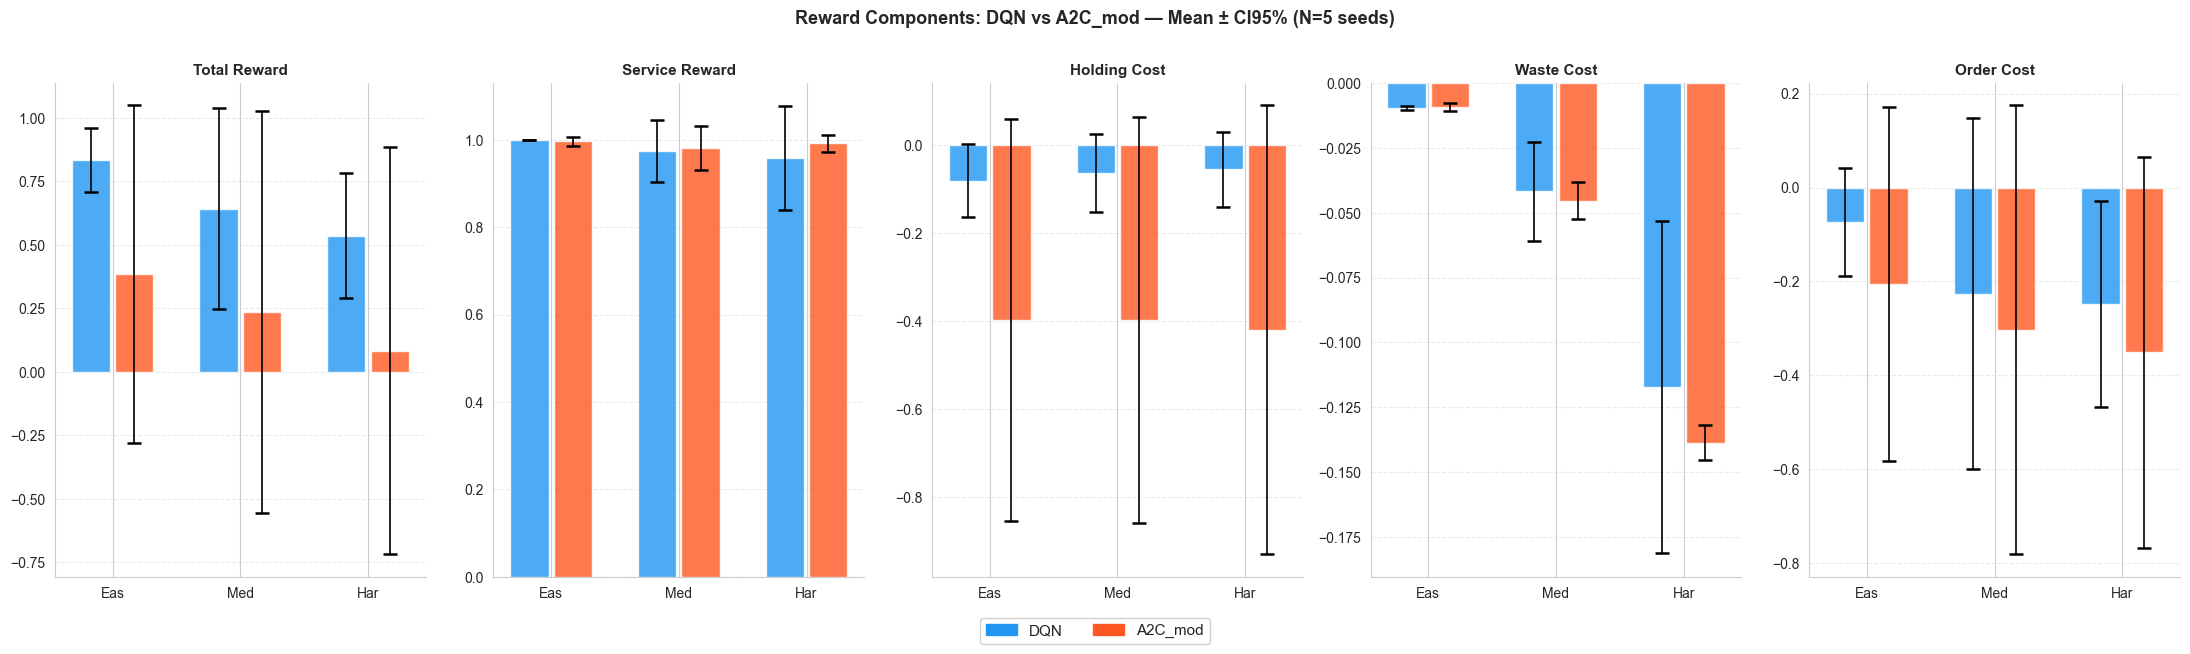

✓ Đã lưu: fig2_reward_components_ci95.png


In [16]:
# ============================================================
# BLOCK 8B: BAR PLOTS — TẤT CẢ REWARD COMPONENTS
# ============================================================

fig, axes = plt.subplots(1, len(METRICS), figsize=(22, 6), sharey=False)
fig.suptitle(
    'Reward Components: DQN vs A2C_mod — Mean ± CI95% (N=5 seeds)',
    fontsize=13, fontweight='bold', y=1.01
)

x_pos = np.arange(len(SCENARIOS))
bar_width = 0.30
gap = 0.04

for ax, metric in zip(axes, METRICS):
    for i, agent_name in enumerate(AGENTS):
        offset = (i - 0.5) * (bar_width + gap)
        means, ci_vals = [], []

        for scenario in SCENARIOS:
            mask = ((df_summary_full['Agent'] == agent_name) &
                    (df_summary_full['Scenario'] == scenario))
            means.append(float(df_summary_full[mask][f'_mean_{metric}']))
            ci_vals.append(float(df_summary_full[mask][f'_ci_{metric}']))

        ax.bar(
            x_pos + offset, means,
            width   = bar_width,
            yerr    = ci_vals,
            color   = AGENT_COLORS[agent_name],
            alpha   = 0.80,
            capsize = 5,
            error_kw= dict(ecolor='black', elinewidth=1.2, capthick=1.8),
            label   = agent_name,
            zorder  = 3,
        )

    ax.set_xticks(x_pos)
    ax.set_xticklabels([s[:3] for s in SCENARIOS], fontsize=10)
    ax.set_title(METRIC_LABELS[metric], fontsize=11, fontweight='bold')
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

handles = [mpatches.Patch(color=AGENT_COLORS[a], label=a) for a in AGENTS]
fig.legend(handles=handles, loc='lower center', ncol=2,
           fontsize=11, framealpha=0.9, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
plt.savefig('fig2_reward_components_ci95.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Đã lưu: fig2_reward_components_ci95.png")

### 8C — Action Stability: Boxplot + Swarmplot (Hard Scenario)

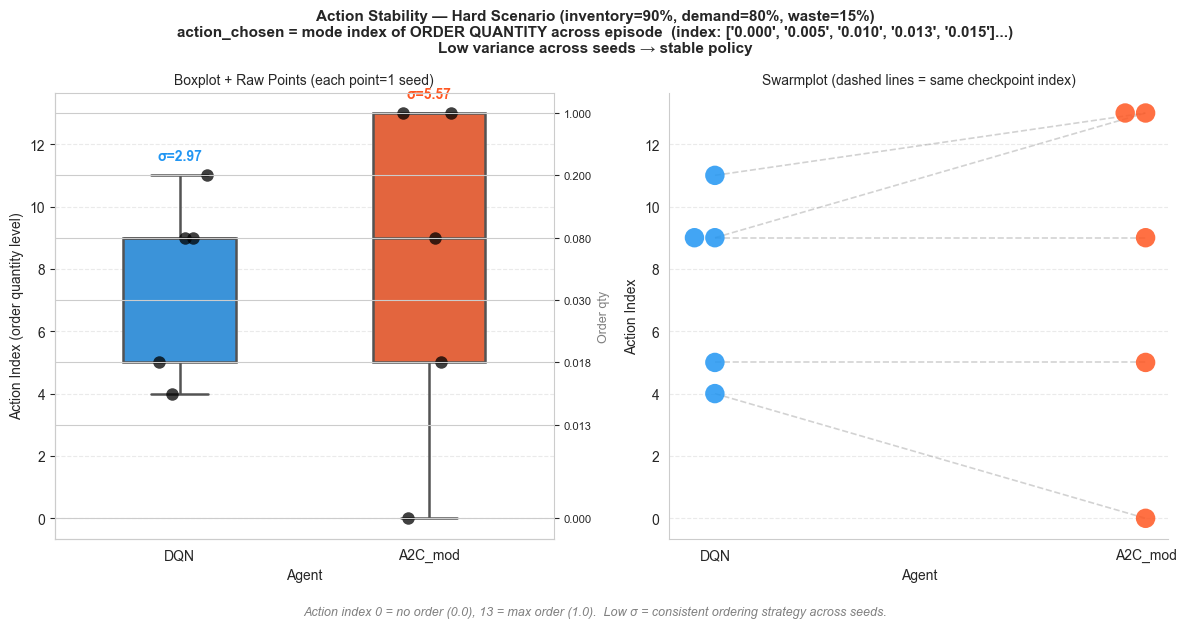

✓ Đã lưu: fig3_action_stability_hard.png


In [17]:
# ============================================================
# BLOCK 8C: ACTION STABILITY — Hard Scenario
# action_chosen: mode action index (0-13) qua toàn bộ episode
# Thấp σ = chính sách ổn định hơn qua các seeds
# ============================================================

df_hard = df_raw[df_raw['scenario'] == 'Hard'].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle(
    'Action Stability — Hard Scenario (inventory=90%, demand=80%, waste=15%)\n'
    f'action_chosen = mode index of ORDER QUANTITY across episode  '
    f'(index: {[f"{v:.3f}" for v in ACTION_SPACE[:5]]}...)\n'
    'Low variance across seeds → stable policy',
    fontsize=11, fontweight='bold'
)

# --- Boxplot + stripplot ---
ax_box = axes[0]
sns.boxplot(
    data=df_hard, x='agent', y='action_chosen',
    order=AGENTS, palette=AGENT_COLORS,
    width=0.45, linewidth=1.8,
    flierprops=dict(marker='D', markersize=7, alpha=0.6),
    ax=ax_box,
)
sns.stripplot(
    data=df_hard, x='agent', y='action_chosen',
    order=AGENTS, color='black',
    size=9, alpha=0.75, jitter=0.12, ax=ax_box,
)
# Annotate σ
for i, agent_name in enumerate(AGENTS):
    vals = df_hard[df_hard['agent'] == agent_name]['action_chosen'].values
    std  = np.std(vals, ddof=1)
    ax_box.text(i, max(vals) + 0.4, f'σ={std:.2f}',
                ha='center', va='bottom', fontsize=10,
                color=AGENT_COLORS[agent_name], fontweight='bold')

ax_box.set_title('Boxplot + Raw Points (each point=1 seed)', fontsize=10)
ax_box.set_ylabel('Action Index (order quantity level)', fontsize=10)
ax_box.set_xlabel('Agent', fontsize=10)
ax_box.yaxis.grid(True, linestyle='--', alpha=0.4)
ax_box.spines[['top','right']].set_visible(False)

# Add secondary y-axis with ACTION_SPACE labels
y_ticks_idx = [0, 3, 5, 7, 9, 11, 13]
ax_box2 = ax_box.twinx()
ax_box2.set_ylim(ax_box.get_ylim())
ax_box2.set_yticks(y_ticks_idx)
ax_box2.set_yticklabels([f'{ACTION_SPACE[j]:.3f}' for j in y_ticks_idx], fontsize=8)
ax_box2.set_ylabel('Order qty', fontsize=9, color='gray')

# --- Swarmplot ---
ax_swarm = axes[1]
sns.swarmplot(
    data=df_hard, x='agent', y='action_chosen',
    order=AGENTS, palette=AGENT_COLORS,
    size=14, alpha=0.85, ax=ax_swarm,
)
# Đường nối cùng seed
for ckpt_idx in range(N_CHECKPOINTS):
    y_vals = []
    for agent_name in AGENTS:
        v = df_hard[(df_hard['agent'] == agent_name) &
                    (df_hard['checkpoint_idx'] == ckpt_idx)]['action_chosen'].values
        y_vals.append(v[0] if len(v) > 0 else np.nan)
    ax_swarm.plot([0, 1], y_vals,
                  color='gray', alpha=0.35, linewidth=1.2, linestyle='--', zorder=1)

ax_swarm.set_title('Swarmplot (dashed lines = same checkpoint index)', fontsize=10)
ax_swarm.set_ylabel('Action Index', fontsize=10)
ax_swarm.set_xlabel('Agent', fontsize=10)
ax_swarm.yaxis.grid(True, linestyle='--', alpha=0.4)
ax_swarm.spines[['top','right']].set_visible(False)

fig.text(
    0.5, -0.03,
    'Action index 0 = no order (0.0), 13 = max order (1.0).  '
    'Low σ = consistent ordering strategy across seeds.',
    ha='center', fontsize=9, color='gray', fontstyle='italic'
)

plt.tight_layout()
plt.savefig('fig3_action_stability_hard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Đã lưu: fig3_action_stability_hard.png")

---
## Block 9 — Action Stability Statistics Table

In [18]:
# ============================================================
# BLOCK 9: ACTION STABILITY — BẢNG SỐ LIỆU
# ============================================================

print("=" * 70)
print("ACTION STABILITY — Hard Scenario (N=5 seeds)")
print("Metric: action_chosen (mode order-quantity index per episode, 0–13)")
print(f"ACTION_SPACE: {ACTION_SPACE.tolist()}")
print("=" * 70)

stability_rows = []
for agent_name in AGENTS:
    vals     = df_hard[df_hard['agent'] == agent_name]['action_chosen'].values
    mean, ci = compute_ci95(vals.astype(float))
    std      = np.std(vals, ddof=1)
    cv       = std / (abs(mean) + 1e-9) * 100

    stability_rows.append({
        'Agent':        agent_name,
        'Raw Indices':  str(vals.tolist()),
        'Qty Values':   str([f"{ACTION_SPACE[v]:.3f}" for v in vals]),
        'Mean±CI95%':   format_mean_ci(mean, ci),
        'σ':            f"{std:.3f}",
        'CV (%)':       f"{cv:.1f}",
        'Min idx':      int(vals.min()),
        'Max idx':      int(vals.max()),
        'Range':        int(vals.max() - vals.min()),
    })

df_stability = pd.DataFrame(stability_rows)
print(df_stability.to_string(index=False))

print("\n--- Diễn giải CV (Coefficient of Variation) ---")
print("  CV < 15%  : chính sách ổn định CAO")
print("  CV 15-30% : ổn định TRUNG BÌNH")
print("  CV > 30%  : KHÔNG ổn định")
for r in stability_rows:
    cv  = float(r['CV (%)'])
    lvl = 'CAO' if cv < 15 else ('TRUNG BÌNH' if cv < 30 else 'THẤP')
    print(f"  {r['Agent']}: CV={cv:.1f}% → Độ ổn định {lvl}")

ACTION STABILITY — Hard Scenario (N=5 seeds)
Metric: action_chosen (mode order-quantity index per episode, 0–13)
ACTION_SPACE: [0.0, 0.004999999888241291, 0.009999999776482582, 0.012500000186264515, 0.014999999664723873, 0.017500000074505806, 0.019999999552965164, 0.029999999329447746, 0.03999999910593033, 0.07999999821186066, 0.11999999731779099, 0.20000000298023224, 0.5, 1.0]
  Agent       Raw Indices                                    Qty Values      Mean±CI95%     σ CV (%)  Min idx  Max idx  Range
    DQN  [4, 11, 9, 9, 5] ['0.015', '0.200', '0.080', '0.080', '0.018'] 7.6000 ± 3.6834 2.966   39.0        4       11      7
A2C_mod [0, 13, 13, 9, 5] ['0.000', '1.000', '1.000', '0.080', '0.018'] 8.0000 ± 6.9133 5.568   69.6        0       13     13

--- Diễn giải CV (Coefficient of Variation) ---
  CV < 15%  : chính sách ổn định CAO
  CV 15-30% : ổn định TRUNG BÌNH
  CV > 30%  : KHÔNG ổn định
  DQN: CV=39.0% → Độ ổn định THẤP
  A2C_mod: CV=69.6% → Độ ổn định THẤP


---
## Block 10 — Summary cho Reviewer

In [19]:
# ============================================================
# BLOCK 10: TÓM TẮT — copy vào Section Results của bài báo
# ============================================================

print("=" * 70)
print("KẾT QUẢ THỐNG KÊ — Section 5 (Results)")
print("=" * 70)

print("""
Phương pháp đánh giá:
  • 5 independent seeds mỗi agent
  • 3 scenarios: Easy (inv=30%, dem=20%, waste=1%),
                 Medium (inv=60%, dem=50%, waste=5%),
                 Hard   (inv=90%, dem=80%, waste=15%)
  • Kết quả: Mean ± CI95% (t-Student, df=4)
  • Kiểm định: Mann-Whitney U (phi tham số, alpha=0.05)
  • Metric: mean reward / timestep (tính trên T={T_MAX} timesteps test)
""".format(T_MAX=T_MAX))

# Pivot table Total Reward
print("Bảng Total Reward (Mean ± CI95%):")
print("-" * 60)
pivot_rows = []
for scenario in SCENARIOS:
    row = {'Scenario': scenario}
    for agent_name in AGENTS:
        mask = ((df_paper_table['Agent'] == agent_name) &
                (df_paper_table['Scenario'] == scenario))
        row[agent_name] = df_paper_table[mask]['Total Reward'].values[0]
    pivot_rows.append(row)
print(pd.DataFrame(pivot_rows).to_string(index=False))

print("\nMann-Whitney U Test (tất cả scenarios):")
print("-" * 60)
print(df_mw[['Scenario','U','p-value','Effect |r|','Significant','Better Agent']
     ].to_string(index=False))

print("\nFiles đã xuất:")
for f in ['raw_results_5seeds.csv',
          'results_ci95.csv',
          'fig1_total_reward_ci95.png',
          'fig2_reward_components_ci95.png',
          'fig3_action_stability_hard.png']:
    print(f"  • {f}")

KẾT QUẢ THỐNG KÊ — Section 5 (Results)

Phương pháp đánh giá:
  • 5 independent seeds mỗi agent
  • 3 scenarios: Easy (inv=30%, dem=20%, waste=1%),
                 Medium (inv=60%, dem=50%, waste=5%),
                 Hard   (inv=90%, dem=80%, waste=15%)
  • Kết quả: Mean ± CI95% (t-Student, df=4)
  • Kiểm định: Mann-Whitney U (phi tham số, alpha=0.05)
  • Metric: mean reward / timestep (tính trên T=604 timesteps test)

Bảng Total Reward (Mean ± CI95%):
------------------------------------------------------------
Scenario             DQN         A2C_mod
    Easy 0.8352 ± 0.1262 0.3853 ± 0.6642
  Medium 0.6433 ± 0.3964 0.2354 ± 0.7916
    Hard 0.5366 ± 0.2453 0.0828 ± 0.8026

Mann-Whitney U Test (tất cả scenarios):
------------------------------------------------------------
Scenario    U p-value Effect |r| Significant Better Agent
    Easy 21.0  0.0952      0.680          no            —
  Medium 20.0  0.1508      0.600          no            —
    Hard 18.0  0.3095      0.440        